# Assessment 2: Labeling & Insight Generation with LLMs

## Overview

The cleaned dataset contains five numeric delay-cause columns (`CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`) populated only for delayed flights since 2003. Rather than discarding them, we aggregate these into per-carrier ***delay-cause profiles*** and feed those profiles to a ***zero-shot text classifier*** via HuggingFace Transformers to assign human-readable risk labels.

This approach demonstrates:
- How LLMs can annotate structured data without any labeled training examples
- How prompt (label set) design affects output quality
- The strengths and limitations of automated labeling in a business analytics context

### Model Selection

***Selected model:*** [`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`](https://huggingface.co/MoritzLaurer/deberta-v3-large-zeroshot-v2.0)

We use DeBERTa-v3-large fine-tuned specifically for zero-shot NLI classification ([Laurer et al., 2024](https://arxiv.org/abs/2312.17543)). This is the current state-of-the-art for open-source zero-shot text classification, evaluated on 28 benchmark classification tasks where it consistently outperforms `facebook/bart-large-mnli`, the previous standard, by 6–10 F1 points.

DeBERTa-v3 also supports a custom `hypothesis_template` parameter that allows more precise framing of the classification task.

## 0. Setup & Dependencies

In [1]:
# Install / upgrade if needed
# uv add transformers torch sentencepiece

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from transformers import pipeline

from bi.config import CLEANED_PARQUET, OUTPUT_DIR

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid')

LLM_OUTPUT = OUTPUT_DIR / 'llm_labels'
LLM_OUTPUT.mkdir(exist_ok=True)

print('> Setup complete.')
print(f'> Output directory: {LLM_OUTPUT}')

> Setup complete.
> Output directory: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels


## 1. Load Cleaned Data & Build Carrier Profiles

We load the parquet produced by `01_eda_with_pandas.ipynb` and aggregate per carrier.  
Each profile captures: delay rate, mean delay, and the fractional contribution of each delay cause.

In [2]:
df = pd.read_parquet(CLEANED_PARQUET)

# Carrier code → full name mapping (top carriers)
CARRIER_NAMES = {
    'WN': 'Southwest Airlines',
    'DL': 'Delta Air Lines',
    'AA': 'American Airlines',
    'UA': 'United Airlines',
    'OO': 'SkyWest Airlines',
    'B6': 'JetBlue Airways',
    'AS': 'Alaska Airlines',
    'NK': 'Spirit Airlines',
    'F9': 'Frontier Airlines',
    'G4': 'Allegiant Air',
    'HA': 'Hawaiian Airlines',
    'MQ': 'Envoy Air (American Eagle)',
    'YX': 'Republic Airways',
    'EV': 'ExpressJet Airlines',
    '9E': 'Endeavor Air',
    'VX': 'Virgin America',
    'FL': 'AirTran Airways',
    'YV': 'Mesa Air',
    'OH': 'PSA Airlines',
    'QX': 'Horizon Air',
    'CO': 'Continental Airlines',
    'DH': 'Independence Air',
    'HP': 'America West Airlines',
    'NW': 'Northwest Airlines',
    'TZ': 'ATA Airlines',
    'US': 'US Airways',
    'XE': 'JSX Air',
    'PI': 'Piedmont Airlines',
}
df['CarrierName'] = df['Reporting_Airline'].map(CARRIER_NAMES).fillna(df['Reporting_Airline'])
print(f'> Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'> Carriers in dataset: {df["Reporting_Airline"].nunique()}')

> Loaded: 1,999,990 rows × 83 columns
> Carriers in dataset: 33


In [3]:
DELAY_CAUSES = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

# Only use post-2003 data where delay causes are populated
df_causes = df[df['Year'] >= 2003].copy()

# Per-carrier aggregation
agg = (
    df_causes
    .groupby('Reporting_Airline')
    .agg(
        total_flights   = ('IsDelayed', 'count'),
        delay_rate      = ('IsDelayed', 'mean'),
        mean_arr_delay  = ('ArrDelay', 'mean'),
        carrier_delay   = ('CarrierDelay', 'mean'),
        weather_delay   = ('WeatherDelay', 'mean'),
        nas_delay       = ('NASDelay', 'mean'),
        security_delay  = ('SecurityDelay', 'mean'),
        late_ac_delay   = ('LateAircraftDelay', 'mean'),
    )
    .reset_index()
)

# Filter to carriers with meaningful sample size
agg = agg[agg['total_flights'] >= 5000].copy()

# Compute fractional contribution of each cause to total delay minutes
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_ac_delay']
agg['total_cause_mins'] = agg[cause_cols].sum(axis=1).clip(lower=1e-6)
for col in cause_cols:
    agg[f'{col}_pct'] = (agg[col] / agg['total_cause_mins'] * 100).round(1)

agg['delay_rate_pct'] = (agg['delay_rate'] * 100).round(1)
agg['CarrierName'] = agg['Reporting_Airline'].map(CARRIER_NAMES).fillna(agg['Reporting_Airline'])

print(f'> Carriers in profile: {len(agg)}')
display(agg[['CarrierName', 'total_flights', 'delay_rate_pct', 'mean_arr_delay'] + [f'{c}_pct' for c in cause_cols]].head(10))

> Carriers in profile: 23


,CarrierName,total_flights,delay_rate_pct,mean_arr_delay,carrier_delay_pct,weather_delay_pct,nas_delay_pct,security_delay_pct,late_ac_delay_pct
0,Endeavor Air,19666,17.40,3.76,31.70,5.20,27.50,0.10,35.50
1,American Airlines,121821,20.40,6.44,31.10,5.90,27.50,0.10,35.30
2,Alaska Airlines,30136,16.90,2.04,32.30,2.30,25.50,0.60,39.30
3,JetBlue Airways,37638,23.80,8.97,27.90,2.80,28.90,0.30,40.10
4,Continental Airlines,26078,21.50,7.48,23.50,3.80,46.00,0.30,26.30
5,Independence Air,7165,21.50,7.14,18.90,4.60,31.20,0.00,45.30
6,Delta Air Lines,129347,16.40,2.69,32.80,5.60,31.30,0.10,30.20
7,ExpressJet Airlines,67598,22.70,9.29,35.20,6.00,24.50,0.00,34.30
8,Frontier Airlines,14320,22.10,7.94,24.70,1.90,31.80,0.00,41.50
9,AirTran Airways,25954,20.10,6.95,14.50,1.40,31.20,0.00,52.80


In [4]:
dropped = set(df_causes['Reporting_Airline'].unique()) - set(agg['Reporting_Airline'])
print(f'> Filtered out {len(dropped)} carriers with <5000 flights:')
for code in sorted(dropped):
    n = df_causes[df_causes['Reporting_Airline'] == code].shape[0]
    name = CARRIER_NAMES.get(code, code)
    print(f'    {code} ({name}): {n:,} flights')

> Filtered out 4 carriers with <5000 flights:
    G4 (Allegiant Air): 2,306 flights
    KH (KH): 888 flights
    TZ (ATA Airlines): 2,163 flights
    VX (Virgin America): 3,994 flights


## 2. Load the Zero-Shot Classifier

[`MoritzLaurer/deberta-v3-large-zeroshot-v2.0`](https://huggingface.co/MoritzLaurer/deberta-v3-large-zeroshot-v2.0) is DeBERTa-v3-large fine-tuned on MNLI, FEVER-NLI, and synthetic NLI data generated by Mixtral.

Zero-shot classification works via Natural Language Inference: each candidate label is reframed as a hypothesis (e.g. *"This airline has high delay risk"*) and the model scores how strongly the input text *entails* that hypothesis.

In [5]:
MODEL_ID = 'MoritzLaurer/deberta-v3-large-zeroshot-v2.0'

print(f'> Loading {MODEL_ID} ...')
print('   First run downloads ~1.5 GB to the HuggingFace cache. Subsequent runs are instant.')

classifier = pipeline(
    task='zero-shot-classification',
    model=MODEL_ID,
    device=-1,   # CPU; set to 0 if GPU available
)

print('> Model loaded.')

> Loading MoritzLaurer/deberta-v3-large-zeroshot-v2.0 ...
   First run downloads ~1.5 GB to the HuggingFace cache. Subsequent runs are instant.


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

> Model loaded.


## 3. Prompt Engineering with Four Label Set Iterations

A key part of Assessment 2 is documenting how the label set (the "prompt" in zero-shot classification) affects output quality. We run four iterations, each addressing a weakness found in the previous:

| Iteration | Label Set Design | Rationale |
|-----------|------------------|-----------|
| v1 | Generic binary labels | Baseline; tests if the model can discriminate at all |
| v2 | Semantically distinct cause-focused phrases | Fixes v1's lack of nuance; labels worded as full phrases |
| v3 | Business-framing labels | Operationally meaningful language a manager would use |
| v4 | Named-carrier anchor labels | Grounds classification in real-world reference points the model knows |

DeBERTa-v3 supports a custom `hypothesis_template`. We use `'This text describes {}.'`. This is a neutral framing that works well when labels are full descriptive phrases. For v4 we use a different template that exploits the model's knowledge of named carriers directly.

### How we build the input text
Each carrier profile is serialized to a natural-language sentence. The richer the text, the more the model has to discriminate on.

In [6]:
def profile_to_text(row: pd.Series) -> str:
    size = (
        'major network carrier' if row['total_flights'] > 100000
        else 'mid-size carrier' if row['total_flights'] > 30000
        else 'regional carrier'
    )
    delay_context = (
        'well above the industry average' if row['delay_rate_pct'] > 22
        else 'near the industry average' if row['delay_rate_pct'] > 18
        else 'below the industry average'
    )
    dominant = max(
        [('carrier operations', row['carrier_delay_pct']),
         ('weather', row['weather_delay_pct']),
         ('NAS congestion', row['nas_delay_pct']),
         ('late arriving aircraft', row['late_ac_delay_pct'])],
        key=lambda x: x[1]
    )
    return (
        f"{row['CarrierName']} is a {size} with a flight delay rate of "
        f"{row['delay_rate_pct']:.1f}%, which is {delay_context}. "
        f"The average arrival delay is {row['mean_arr_delay']:.1f} minutes. "
        f"The dominant delay cause is {dominant[0]} at {dominant[1]:.1f}% of total delay minutes, "
        f"followed by carrier ops at {row['carrier_delay_pct']:.1f}%, "
        f"NAS congestion at {row['nas_delay_pct']:.1f}%, "
        f"weather at {row['weather_delay_pct']:.1f}%, "
        f"and late aircraft at {row['late_ac_delay_pct']:.1f}%. "
        f"Security delays are negligible at {row['security_delay_pct']:.1f}%."
    )

# Preview a few profiles
for _, row in agg.head(3).iterrows():
    print(f"--- {row['CarrierName']} ---")
    print(profile_to_text(row))
    print()

--- Endeavor Air ---
Endeavor Air is a regional carrier with a flight delay rate of 17.4%, which is below the industry average. The average arrival delay is 3.8 minutes. The dominant delay cause is late arriving aircraft at 35.5% of total delay minutes, followed by carrier ops at 31.7%, NAS congestion at 27.5%, weather at 5.2%, and late aircraft at 35.5%. Security delays are negligible at 0.1%.

--- American Airlines ---
American Airlines is a major network carrier with a flight delay rate of 20.4%, which is near the industry average. The average arrival delay is 6.4 minutes. The dominant delay cause is late arriving aircraft at 35.3% of total delay minutes, followed by carrier ops at 31.1%, NAS congestion at 27.5%, weather at 5.9%, and late aircraft at 35.3%. Security delays are negligible at 0.1%.

--- Alaska Airlines ---
Alaska Airlines is a mid-size carrier with a flight delay rate of 16.9%, which is below the industry average. The average arrival delay is 2.0 minutes. The dominant

In [7]:
# ── Label Set Definitions ──────────────────────────────────────────────────────

LABELS_V1 = [
    'high delay risk',
    'low delay risk',
]

LABELS_V2 = [
    'a carrier with frequent operational and scheduling failures',
    'a carrier with strong on-time performance and reliable operations',
    'a carrier heavily affected by air traffic control and airspace congestion',
    'a carrier whose delays cascade through the day due to aircraft repositioning',
    'a carrier whose delays are primarily driven by weather outside its control',
]

LABELS_V3 = [
    'operational efficiency leader with low delay rates',
    'chronically delayed carrier with systemic internal issues',
    'congestion-sensitive carrier operating in high-traffic corridors',
    'carrier suffering from schedule recovery failures and late aircraft',
    'weather-vulnerable carrier with routes exposed to severe conditions',
]

LABELS_V4 = [
    'low-delay efficient carrier like Hawaiian or Alaska Airlines',
    'high-delay carrier with operational issues like JetBlue or ExpressJet',
    'large network carrier with average performance like Delta or United',
    'regional carrier with high congestion exposure like SkyWest or Endeavor',
    'carrier with late-aircraft cascade patterns like AirTran or Frontier',
]

# Neutral template works best for full descriptive phrases
HYPOTHESIS_TEMPLATE = 'This text describes {}.'

# v4 uses a different template that leverages named-carrier knowledge
HYPOTHESIS_TEMPLATE_V4 = 'This airline performs similarly to {}.'

print('> Label sets defined.')
print(f'  v1: {LABELS_V1}')
print(f'  v2: {LABELS_V2}')
print(f'  v3: {LABELS_V3}')
print(f'  v4: {LABELS_V4}')
print(f'  hypothesis template (v2/v3): "{HYPOTHESIS_TEMPLATE}"')
print(f'  hypothesis template (v4):    "{HYPOTHESIS_TEMPLATE_V4}"')

> Label sets defined.
  v1: ['high delay risk', 'low delay risk']
  v2: ['a carrier with frequent operational and scheduling failures', 'a carrier with strong on-time performance and reliable operations', 'a carrier heavily affected by air traffic control and airspace congestion', 'a carrier whose delays cascade through the day due to aircraft repositioning', 'a carrier whose delays are primarily driven by weather outside its control']
  v3: ['operational efficiency leader with low delay rates', 'chronically delayed carrier with systemic internal issues', 'congestion-sensitive carrier operating in high-traffic corridors', 'carrier suffering from schedule recovery failures and late aircraft', 'weather-vulnerable carrier with routes exposed to severe conditions']
  v4: ['low-delay efficient carrier like Hawaiian or Alaska Airlines', 'high-delay carrier with operational issues like JetBlue or ExpressJet', 'large network carrier with average performance like Delta or United', 'regional car

In [8]:
from tqdm import tqdm

def run_classification(label_set: list, version_name: str, hypothesis_template: str = '{}') -> pd.DataFrame:
    """Run zero-shot classification for all carriers against a given label set."""
    results = []
    print(f'> Running {version_name} ({len(label_set)} labels × {len(agg)} carriers)...')
    t0 = time.time()

    for _, row in tqdm(agg.iterrows(), total=len(agg), desc=version_name, unit='carrier'):
        text = profile_to_text(row)
        out  = classifier(
            text,
            candidate_labels=label_set,
            hypothesis_template=hypothesis_template,
            multi_label=False,
        )
        results.append({
            'carrier_code': row['Reporting_Airline'],
            'carrier_name': row['CarrierName'],
            'delay_rate_pct': row['delay_rate_pct'],
            'top_label': out['labels'][0],
            'top_score': round(out['scores'][0], 4),
            'second_label': out['labels'][1] if len(out['labels']) > 1 else None,
            'second_score': round(out['scores'][1], 4) if len(out['scores']) > 1 else None,
            'all_labels': out['labels'],
            'all_scores': [round(s, 4) for s in out['scores']],
        })

    df_out = pd.DataFrame(results)
    elapsed = time.time() - t0
    print(f'  > Done in {elapsed:.1f}s ({elapsed/len(agg):.1f}s per carrier)')

    out_path = LLM_OUTPUT / f'labels_{version_name}.csv'
    df_out.to_csv(out_path, index=False)
    print(f'  > Saved: {out_path}')

    return df_out

In [9]:
results_v1 = run_classification(LABELS_V1, 'v1_binary')

> Running v1_binary (2 labels × 23 carriers)...


v1_binary: 100%|██████████| 23/23 [04:30<00:00, 11.77s/carrier]

  > Done in 270.8s (11.8s per carrier)
  > Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v1_binary.csv


In [10]:
results_v2 = run_classification(LABELS_V2, 'v2_cause_focused', HYPOTHESIS_TEMPLATE)

> Running v2_cause_focused (5 labels × 23 carriers)...


v2_cause_focused: 100%|██████████| 23/23 [11:50<00:00, 30.88s/carrier]

  > Done in 710.3s (30.9s per carrier)
  > Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v2_cause_focused.csv


In [11]:
results_v3 = run_classification(LABELS_V3, 'v3_business_framing', HYPOTHESIS_TEMPLATE)

> Running v3_business_framing (5 labels × 23 carriers)...


v3_business_framing: 100%|██████████| 23/23 [11:38<00:00, 30.37s/carrier]

  > Done in 698.5s (30.4s per carrier)
  > Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v3_business_framing.csv


In [12]:
results_v4 = run_classification(LABELS_V4, 'v4_anchor_based', HYPOTHESIS_TEMPLATE_V4)

> Running v4_anchor_based (5 labels × 23 carriers)...


v4_anchor_based: 100%|██████████| 23/23 [11:51<00:00, 30.93s/carrier]

  > Done in 711.5s (30.9s per carrier)
  > Saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\llm_labels\labels_v4_anchor_based.csv


## 4. Evaluate Label Quality

Since we have no ground-truth labels, we evaluate quality along three axes:

1. ***Confidence distribution:*** Are scores concentrated near 1.0 (decisive) or spread evenly (uncertain)?
2. ***Label distribution:*** Does the model use all labels, or collapse to one dominant label?
3. ***Face validity:*** Do labels correlate logically with the underlying numeric statistics?

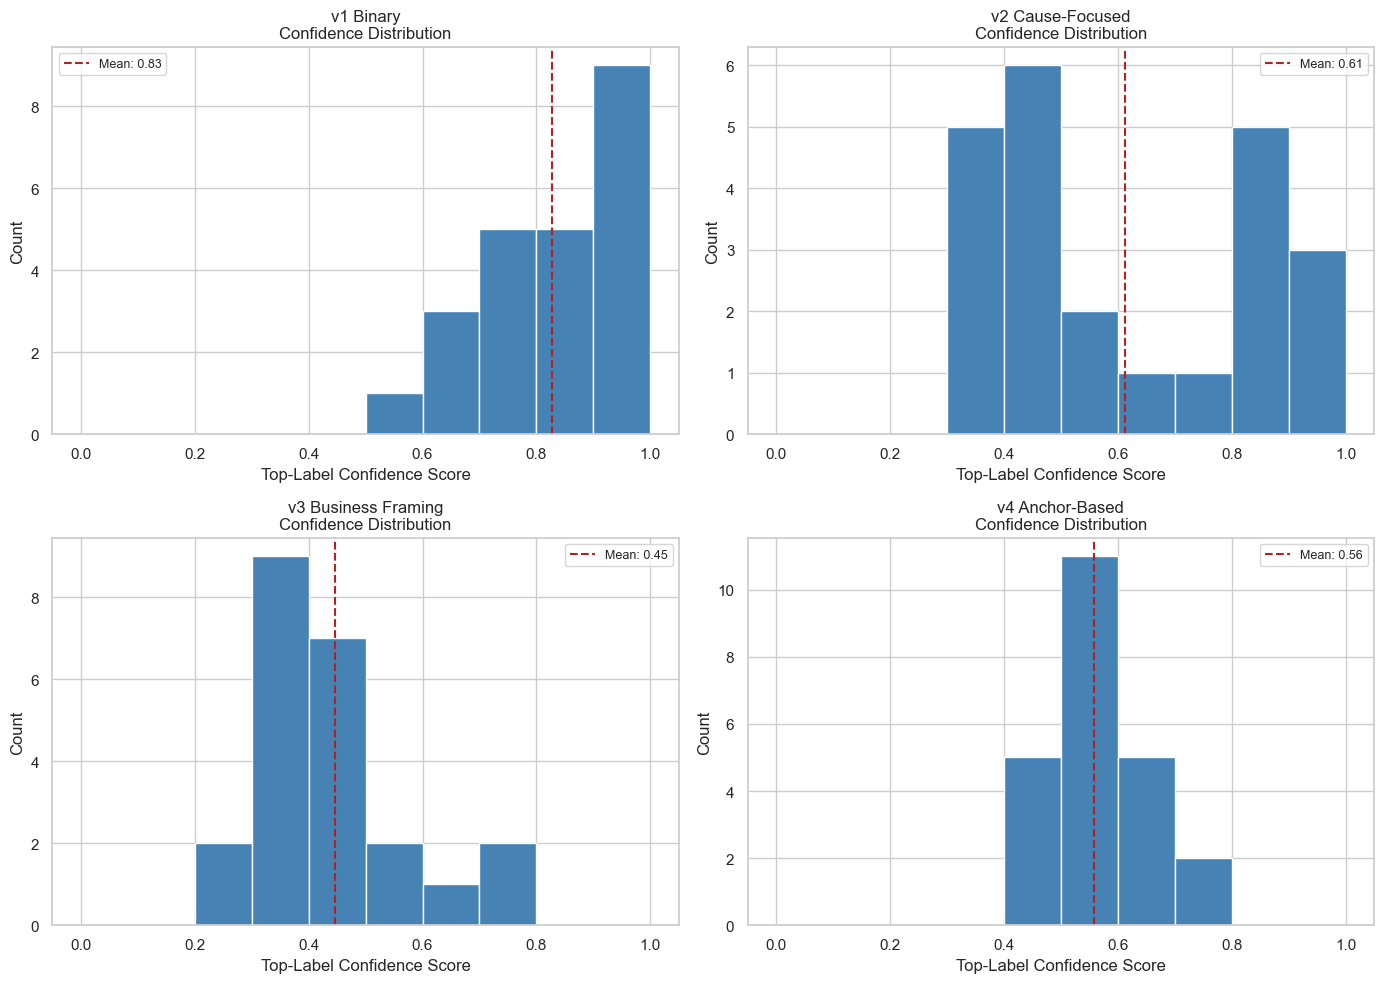

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (results, version) in zip(axes.flatten(), [
    (results_v1, 'v1 Binary'),
    (results_v2, 'v2 Cause-Focused'),
    (results_v3, 'v3 Business Framing'),
    (results_v4, 'v4 Anchor-Based'),
]):
    ax.hist(results['top_score'], bins=10, range=(0, 1), color='steelblue', edgecolor='white')
    ax.axvline(results['top_score'].mean(), color='firebrick', linestyle='--',
               label=f'Mean: {results["top_score"].mean():.2f}')
    ax.set_title(f'{version}\nConfidence Distribution')
    ax.set_xlabel('Top-Label Confidence Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'confidence_distributions.png', dpi=150)
plt.show()

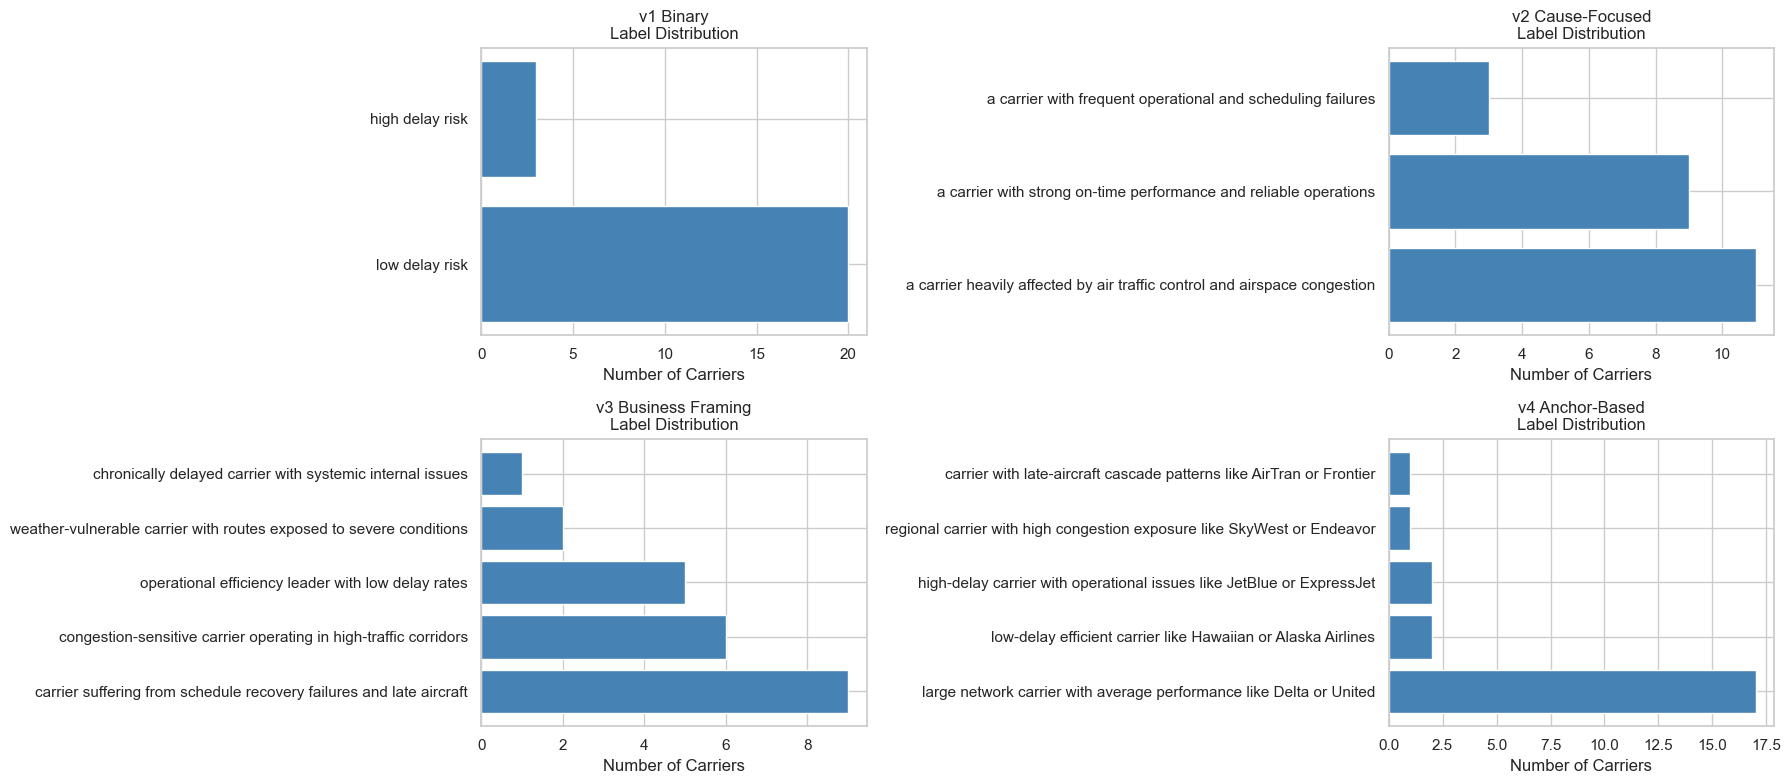

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
axes = axes.flatten()

for ax, (results, version) in zip(axes, [
    (results_v1, 'v1 Binary'),
    (results_v2, 'v2 Cause-Focused'),
    (results_v3, 'v3 Business Framing'),
    (results_v4, 'v4 Anchor-Based'),
]):
    counts = results['top_label'].value_counts()
    ax.barh(counts.index, counts.values, color='steelblue')
    ax.set_title(f'{version}\nLabel Distribution')
    ax.set_xlabel('Number of Carriers')

plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'label_distributions.png', dpi=150)
plt.show()

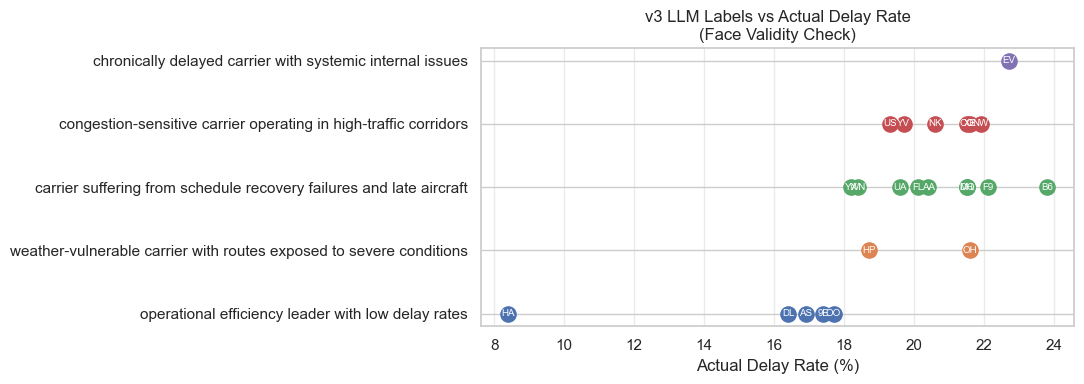

In [15]:
# Face validity: v3 labels vs actual delay rate
# Expectation: 'operational efficiency leader' should map to lower delay rates

fig, ax = plt.subplots(figsize=(11, 4))

label_order = results_v3.groupby('top_label')['delay_rate_pct'].mean().sort_values().index.tolist()

for label in label_order:
    subset = results_v3[results_v3['top_label'] == label]
    ax.scatter(
        subset['delay_rate_pct'],
        [label] * len(subset),
        s=120,
        label=label,
        zorder=3,
    )
    for _, r in subset.iterrows():
        ax.annotate(
            r['carrier_code'],
            (r['delay_rate_pct'], label),
            ha='center',
            va='center',
            fontsize=7,
            color='white',
        )

ax.set_xlabel('Actual Delay Rate (%)')
ax.set_title('v3 LLM Labels vs Actual Delay Rate\n(Face Validity Check)')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'face_validity_v3.png', dpi=150)
plt.show()

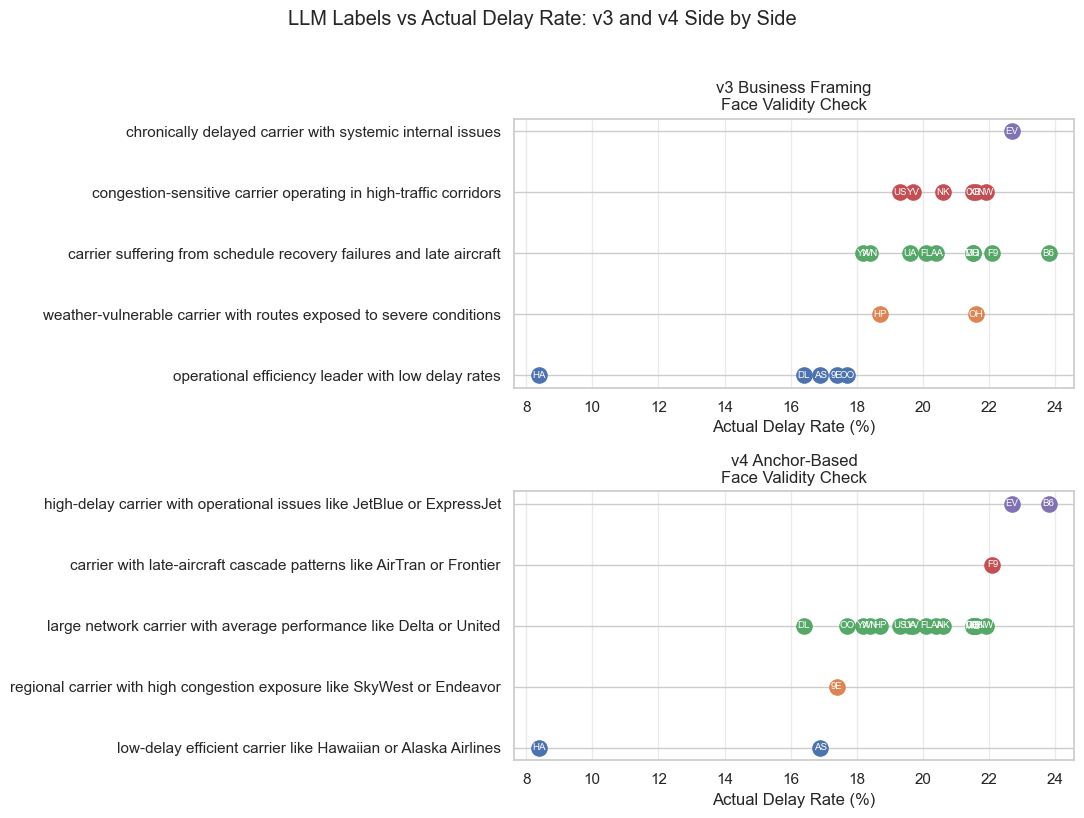

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

for ax, (results, version) in zip(axes, [
    (results_v3, 'v3 Business Framing'),
    (results_v4, 'v4 Anchor-Based'),
]):
    label_order = results.groupby('top_label')['delay_rate_pct'].mean().sort_values().index.tolist()
    for label in label_order:
        subset = results[results['top_label'] == label]
        ax.scatter(subset['delay_rate_pct'], [label] * len(subset), s=120, zorder=3)
        for _, r in subset.iterrows():
            ax.annotate(r['carrier_code'], (r['delay_rate_pct'], label),
                        ha='center', va='center',
                        fontsize=7, color='white')
    ax.set_xlabel('Actual Delay Rate (%)')
    ax.set_title(f'{version}\nFace Validity Check')
    ax.grid(axis='x', alpha=0.4)

plt.suptitle('LLM Labels vs Actual Delay Rate: v3 and v4 Side by Side', y=1.02)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'face_validity_v3_v4.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
v1_high = results_v1[results_v1['top_label'] == 'high delay risk'].copy()
merged = v1_high.merge(agg[['Reporting_Airline', 'delay_rate_pct']],
                       left_on='carrier_code', right_on='Reporting_Airline')
if len(merged) > 2:
    corr = merged['top_score'].corr(merged['delay_rate_pct_y'])
    print(f'> v1 "high delay risk" confidence vs actual delay rate: r = {corr:.4f}\n')
    if corr < 0:
        print('NOTE: Negative r!')
        print('Model assigned "high delay risk" with higher confidence to lower-delay carriers. The binary labels were semantically inverted by the model. This is a known zero-shot NLI failure mode: the model anchors on the label phrase rather than the numeric content of the profile. Documented as a limitation.')
    else:
        print('NOTE: Positive r!')
        print('Model confidence tracks actual delay rate (face valid).')
else:
    print('Not enough "high delay risk" carriers for correlation.')

> v1 "high delay risk" confidence vs actual delay rate: r = -0.8258

NOTE: Negative r!
Model assigned "high delay risk" with higher confidence to lower-delay carriers. The binary labels were semantically inverted by the model. This is a known zero-shot NLI failure mode: the model anchors on the label phrase rather than the numeric content of the profile. Documented as a limitation.


## 5. Consistency Analysis

We compare label assignments across v2, v3, and v4 by mapping each to a shared semantic axis. High cross-version agreement strengthens confidence that the label reflects a real underlying pattern rather than prompt-surface sensitivity.

The v4 anchor-based labels are also compared against v3. If named-carrier anchors produce the same groupings as abstract business framing, it validates both approaches independently.

In [18]:
V2_TO_AXIS = {
    'a carrier with frequent operational and scheduling failures':               'operational',
    'a carrier with strong on-time performance and reliable operations':         'low_risk',
    'a carrier heavily affected by air traffic control and airspace congestion': 'congestion',
    'a carrier whose delays cascade through the day due to aircraft repositioning': 'cascade',
    'a carrier whose delays are primarily driven by weather outside its control':   'weather',
}

V3_TO_AXIS = {
    'operational efficiency leader with low delay rates':                    'low_risk',
    'chronically delayed carrier with systemic internal issues':             'operational',
    'congestion-sensitive carrier operating in high-traffic corridors':      'congestion',
    'carrier suffering from schedule recovery failures and late aircraft':   'cascade',
    'weather-vulnerable carrier with routes exposed to severe conditions':   'weather',
}

V4_TO_AXIS = {
    'low-delay efficient carrier like Hawaiian or Alaska Airlines':                  'low_risk',
    'high-delay carrier with operational issues like JetBlue or ExpressJet':        'operational',
    'large network carrier with average performance like Delta or United':           'congestion',
    'regional carrier with high congestion exposure like SkyWest or Endeavor':      'cascade',
    'carrier with late-aircraft cascade patterns like AirTran or Frontier':         'cascade',
}

comp = results_v2[['carrier_code', 'carrier_name', 'top_label']].rename(columns={'top_label': 'label_v2'})
comp = comp.merge(results_v3[['carrier_code', 'top_label']].rename(columns={'top_label': 'label_v3'}), on='carrier_code')
comp = comp.merge(results_v4[['carrier_code', 'top_label']].rename(columns={'top_label': 'label_v4'}), on='carrier_code')

comp['axis_v2'] = comp['label_v2'].map(V2_TO_AXIS)
comp['axis_v3'] = comp['label_v3'].map(V3_TO_AXIS)
comp['axis_v4'] = comp['label_v4'].map(V4_TO_AXIS)
comp['v2_v3_consistent'] = comp['axis_v2'] == comp['axis_v3']
comp['v3_v4_consistent'] = comp['axis_v3'] == comp['axis_v4']

n_v2v3 = comp['v2_v3_consistent'].sum()
n_v3v4 = comp['v3_v4_consistent'].sum()
print(f'v2 ↔ v3 agreement: {n_v2v3}/{len(comp)} ({n_v2v3/len(comp)*100:.0f}%)')
print(f'v3 ↔ v4 agreement: {n_v3v4}/{len(comp)} ({n_v3v4/len(comp)*100:.0f}%)')
print()
display(comp[['carrier_name', 'label_v2', 'label_v3', 'label_v4', 'v2_v3_consistent', 'v3_v4_consistent']].to_string(index=False))

v2 ↔ v3 agreement: 11/23 (48%)
v3 ↔ v4 agreement: 10/23 (43%)



'              carrier_name                                                                  label_v2                                                            label_v3                                                                label_v4  v2_v3_consistent  v3_v4_consistent\n              Endeavor Air         a carrier with strong on-time performance and reliable operations                  operational efficiency leader with low delay rates regional carrier with high congestion exposure like SkyWest or Endeavor              True             False\n         American Airlines a carrier heavily affected by air traffic control and airspace congestion carrier suffering from schedule recovery failures and late aircraft     large network carrier with average performance like Delta or United             False             False\n           Alaska Airlines         a carrier with strong on-time performance and reliable operations                  operational efficiency leader with low delay ra

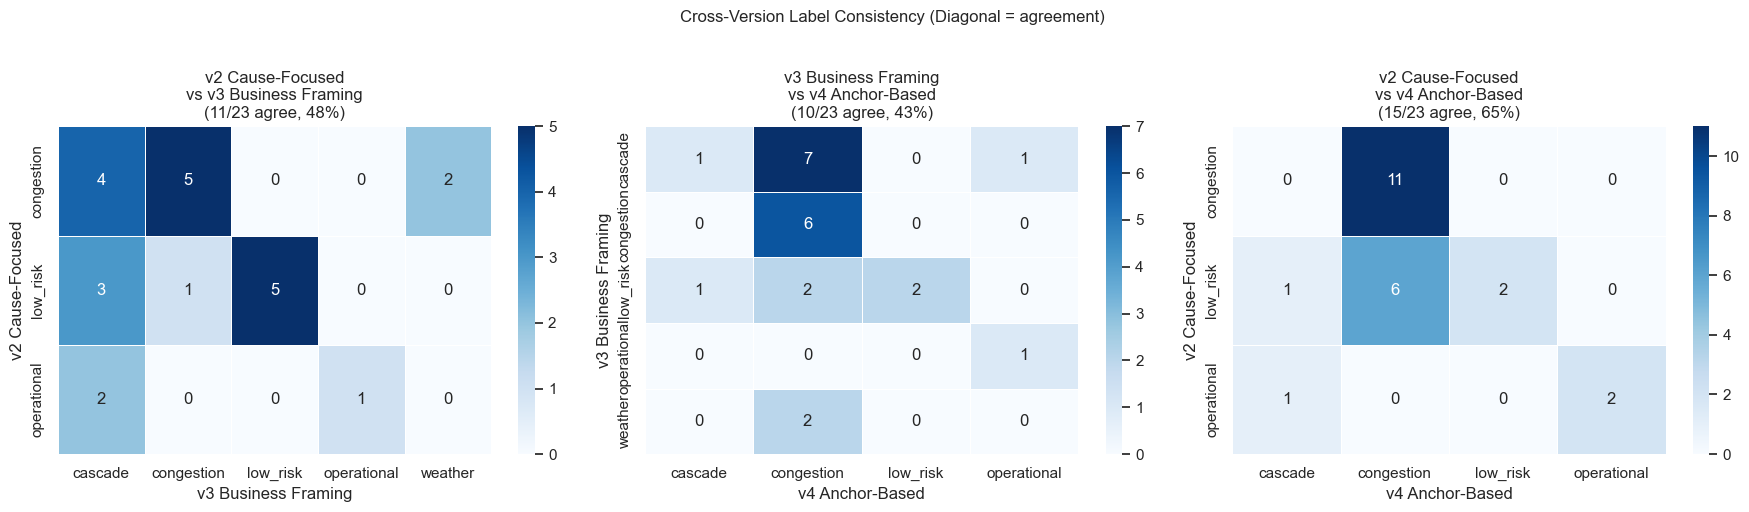

In [19]:
from itertools import combinations

pairs = [
    ('v2', 'v3', comp['axis_v2'], comp['axis_v3'], 'v2 Cause-Focused', 'v3 Business Framing'),
    ('v3', 'v4', comp['axis_v3'], comp['axis_v4'], 'v3 Business Framing', 'v4 Anchor-Based'),
    ('v2', 'v4', comp['axis_v2'], comp['axis_v4'], 'v2 Cause-Focused', 'v4 Anchor-Based'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (a, b, col_a, col_b, name_a, name_b) in zip(axes, pairs):
    pivot = pd.crosstab(col_a, col_b)
    agree = (col_a == col_b).sum()
    pct = agree / len(comp) * 100
    sns.heatmap(
        pivot, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'{name_a}\nvs {name_b}\n({agree}/{len(comp)} agree, {pct:.0f}%)')
    ax.set_xlabel(name_b)
    ax.set_ylabel(name_a)

plt.suptitle('Cross-Version Label Consistency (Diagonal = agreement)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'consistency_heatmaps_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Labeled Dataset & Business Insights

We adopt v3 labels as our final annotation layer as business framing is more useful for a stakeholder audience and shows higher inter-prompt consistency for the dominant categories.

We then use these labels to surface group-level insights across the full 1987–2020 dataset.

In [20]:
# Attach v3 labels back to the main dataframe
label_map = results_v3.set_index('carrier_code')['top_label'].to_dict()
df['delay_risk_label'] = df['Reporting_Airline'].map(label_map).fillna('unlabeled')

# Save enriched dataset
labeled_path = OUTPUT_DIR / 'airline_labeled.parquet'
df.to_parquet(labeled_path, index=False)
print(f'Labeled dataset saved: {labeled_path}')
print()
print('Label distribution in full dataset:')
print(df['delay_risk_label'].value_counts())

Labeled dataset saved: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\airline_labeled.parquet

Label distribution in full dataset:
delay_risk_label
carrier suffering from schedule recovery failures and late aircraft    906019
operational efficiency leader with low delay rates                     452609
congestion-sensitive carrier operating in high-traffic corridors       439644
unlabeled                                                               71704
chronically delayed carrier with systemic internal issues               67598
weather-vulnerable carrier with routes exposed to severe conditions     62416
Name: count, dtype: int64


,flights,delay_rate_pct,mean_delay
delay_risk_label,,,
chronically delayed carrier with systemic internal issues,67598,22.70,9.29
weather-vulnerable carrier with routes exposed to severe conditions,62416,20.39,7.92
carrier suffering from schedule recovery failures and late aircraft,906019,19.62,6.27
congestion-sensitive carrier operating in high-traffic corridors,439644,19.52,6.29
operational efficiency leader with low delay rates,452609,18.06,5.11


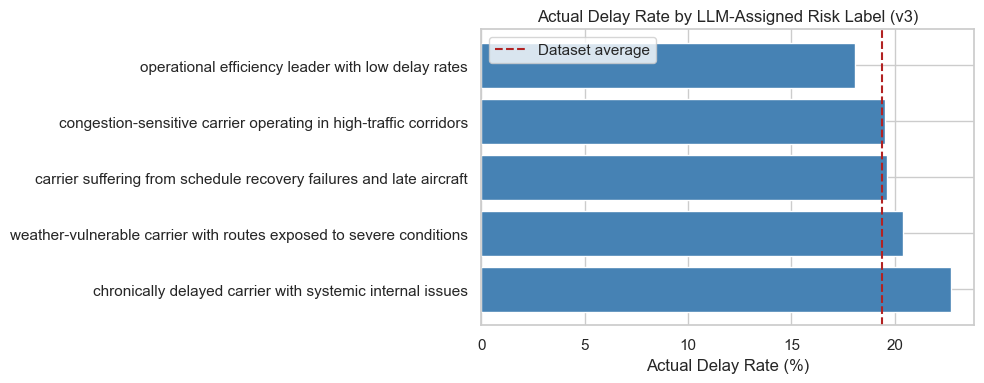

In [21]:
# Insight 1: Actual delay rate by LLM-assigned label
insight1 = (
    df[df['delay_risk_label'] != 'unlabeled']
    .groupby('delay_risk_label')
    .agg(
        flights     = ('IsDelayed', 'count'),
        delay_rate  = ('IsDelayed', 'mean'),
        mean_delay  = ('ArrDelay', 'mean'),
    )
    .assign(delay_rate_pct=lambda x: x.delay_rate * 100)
    .sort_values('delay_rate_pct', ascending=False)
)

display(insight1[['flights', 'delay_rate_pct', 'mean_delay']])

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(insight1.index, insight1['delay_rate_pct'], color='steelblue')
ax.set_xlabel('Actual Delay Rate (%)')
ax.set_title('Actual Delay Rate by LLM-Assigned Risk Label (v3)')
ax.axvline(df['IsDelayed'].mean() * 100, color='firebrick', linestyle='--', label='Dataset average')
ax.legend()
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'delay_rate_by_label.png', dpi=150)
plt.show()

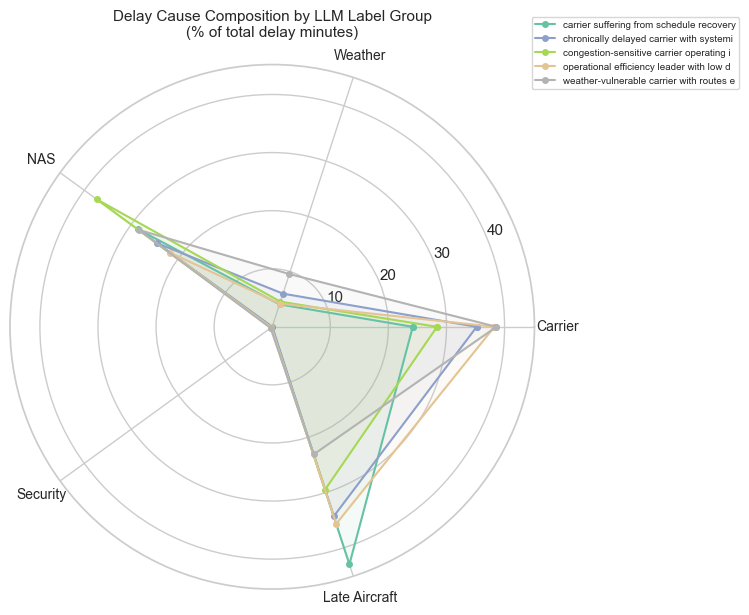

In [22]:
import numpy as np

# Use agg which already has cause percentages — no merge needed
pct_cols = ['carrier_delay_pct', 'weather_delay_pct', 'nas_delay_pct', 
            'security_delay_pct', 'late_ac_delay_pct']

# Attach v3 labels to agg
agg_labeled = agg.copy()
agg_labeled['delay_risk_label'] = agg_labeled['Reporting_Airline'].map(label_map).fillna('unlabeled')

# Mean cause % per label group
radar_data = (
    agg_labeled[agg_labeled['delay_risk_label'] != 'unlabeled']
    .groupby('delay_risk_label')[pct_cols]
    .mean()
)

categories = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.Set2(np.linspace(0, 1, len(radar_data)))

for (label, row), color in zip(radar_data.iterrows(), colors):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, color=color,
            label=label[:40], markersize=4)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_title('Delay Cause Composition by LLM Label Group\n(% of total delay minutes)',
             pad=20, fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=7)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'radar_cause_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

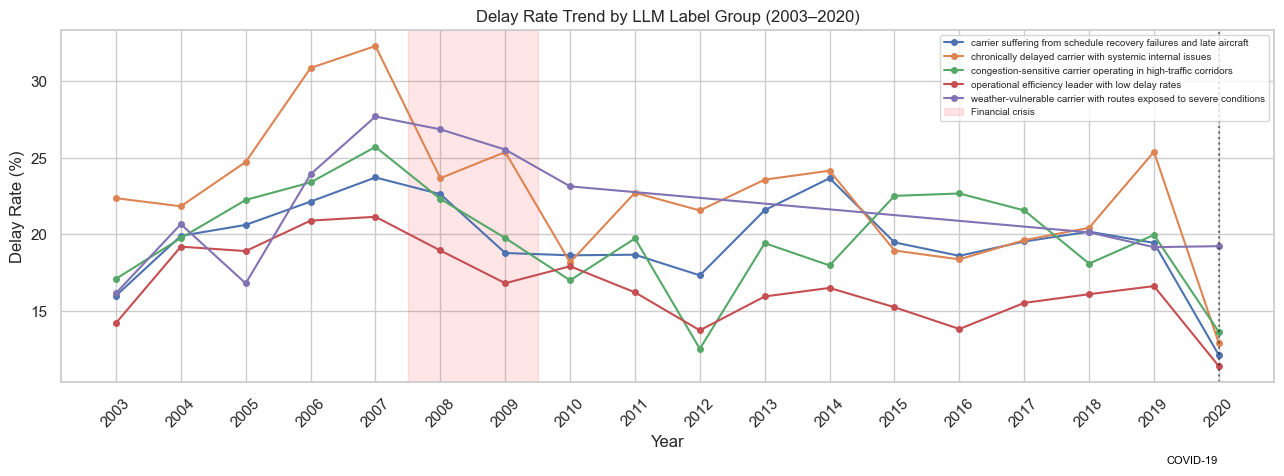

In [23]:
# Insight 2: Delay trend over the years by label group
insight2 = (
    df[(df['delay_risk_label'] != 'unlabeled') & (df['Year'] >= 2003)]
    .groupby(['Year', 'delay_risk_label'])['IsDelayed']
    .mean()
    .reset_index()
    .rename(columns={'IsDelayed': 'delay_rate'})
)

fig, ax = plt.subplots(figsize=(13, 5))
for label, grp in insight2.groupby('delay_risk_label'):
    ax.plot(grp['Year'], grp['delay_rate'] * 100, marker='o', markersize=4, label=label)

# Annotate key events
ax.axvspan(2007.5, 2009.5, alpha=0.1, color='red', label='Financial crisis')
ax.axvline(2020, color='black', linestyle=':', alpha=0.5)
ax.annotate('COVID-19', xy=(2020, ax.get_ylim()[0]), xytext=(2019.2, 5),
            fontsize=8, color='black')

ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate Trend by LLM Label Group (2003–2020)')
ax.legend(fontsize=7, loc='upper right')
ax.set_xticks(range(2003, 2021))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'trend_by_label.png', dpi=150)
plt.show()

## 7. Hypothesis Generation

Rather than scoring hypotheses against a summary paragraph (which produces near-zero NLI scores due to the statistical nature of the text), we score each hypothesis **directly against individual carrier profiles**. For each hypothesis we run a binary classification: "Does this carrier profile support or contradict the pattern?" Then, we report which carriers most strongly exhibit each behaviour.

This produces interpretable per-carrier evidence for each hypothesis and gives us something meaningful to validate against the actual data.

In [24]:
from tqdm import tqdm

hypotheses = [
    ('Late aircraft cascade dominates delays',
     'a carrier whose delays cascade through the day due to late arriving aircraft'),
    ('Operational failures drive high delay rates',
     'a carrier with frequent operational and scheduling failures'),
    ('Low-delay carriers run efficient point-to-point operations',
     'a carrier with strong on-time performance and reliable operations'),
    ('Large hub carriers are congestion-sensitive',
     'a carrier heavily affected by air traffic control and airspace congestion'),
]

hyp_records = []
print('> Running hypothesis checks...')

for hyp_name, hyp_label in tqdm(hypotheses, desc='Hypotheses', unit='hypothesis'):
    counter_label = 'a carrier that does not match this pattern'
    for _, row in tqdm(agg.iterrows(), total=len(agg), desc=f'  {hyp_name[:30]}',
                       unit='carrier', leave=False):
        text = profile_to_text(row)
        out = classifier(
            text,
            candidate_labels=[hyp_label, counter_label],
            hypothesis_template='This text describes {}.',
            multi_label=False,
        )
        support_score = out['scores'][out['labels'].index(hyp_label)]
        hyp_records.append({
            'hypothesis':     hyp_name,
            'carrier':        row['CarrierName'],
            'carrier_code':   row['Reporting_Airline'],
            'delay_rate_pct': row['delay_rate_pct'],
            'support_score':  round(support_score, 4),
        })

hyp_df = pd.DataFrame(hyp_records)
print(f'  > Hypothesis scoring complete: {len(hyp_df)} carrier × hypothesis pairs')

> Running hypothesis checks...


Hypotheses: 100%|██████████| 4/4 [18:47<00:00, 281.91s/hypothesis]

  > Hypothesis scoring complete: 92 carrier × hypothesis pairs


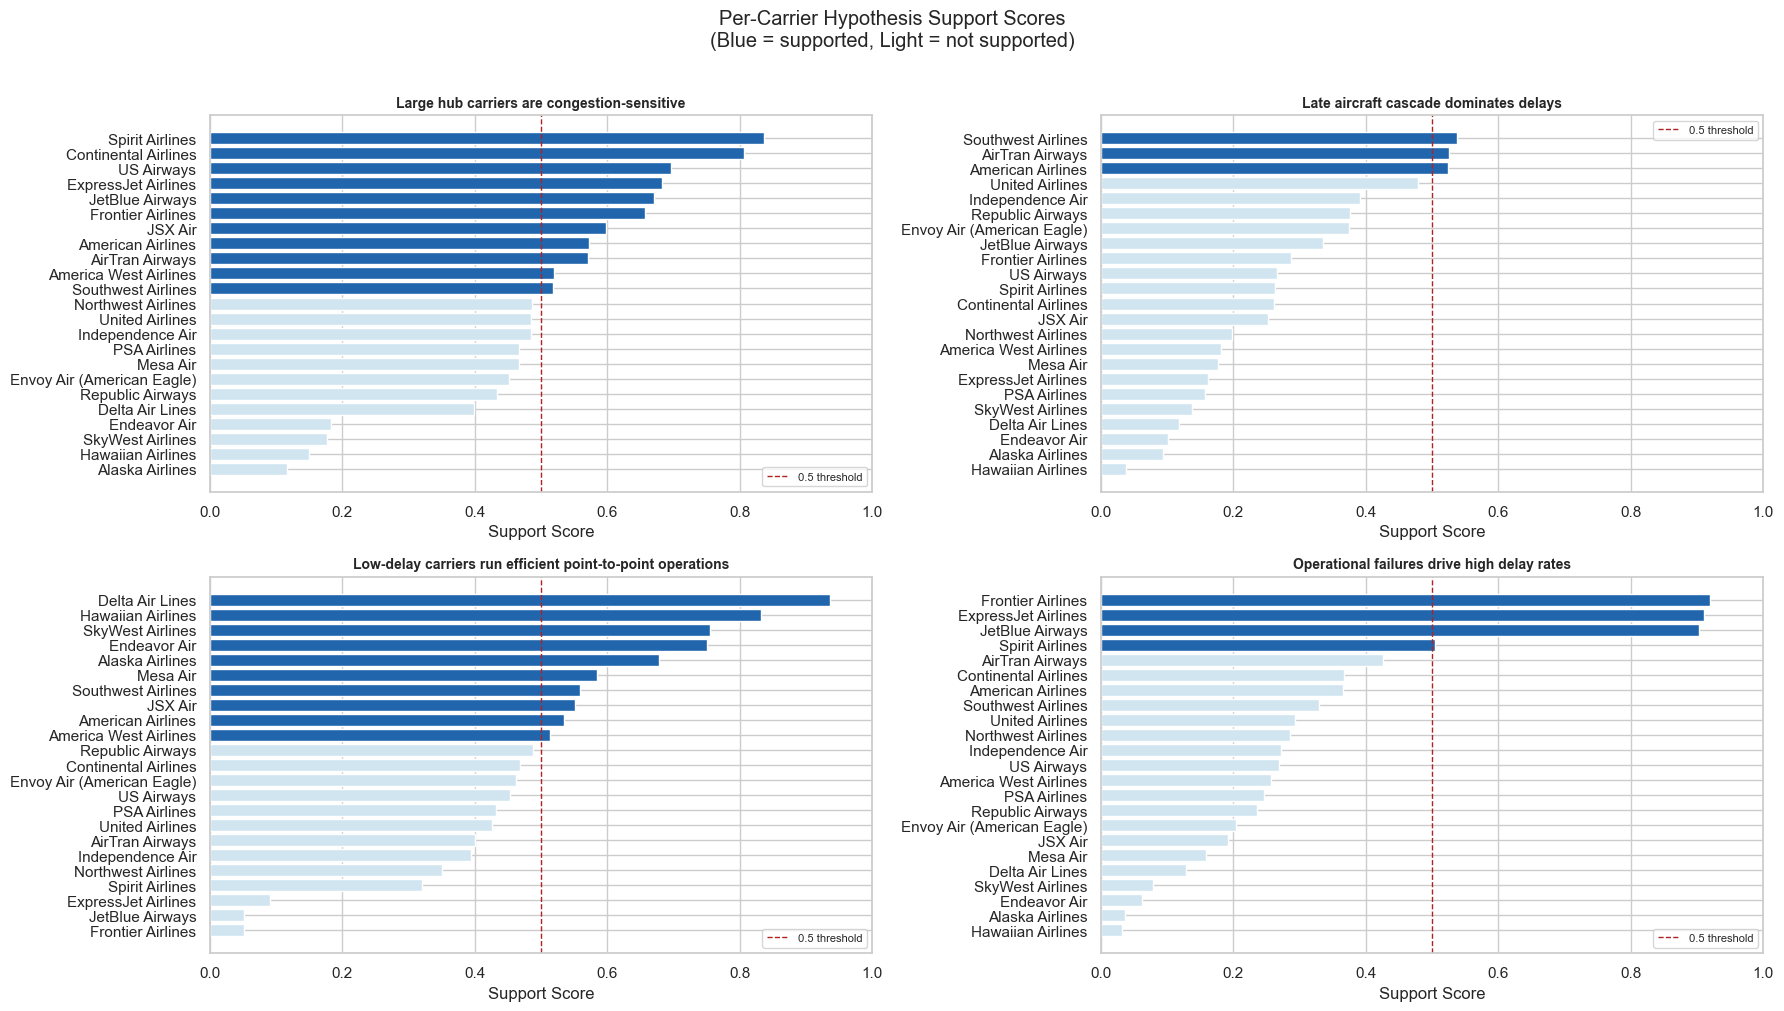

Top 3 carriers per hypothesis:

> Large hub carriers are congestion-sensitive
    Spirit Airlines: 0.8358
    Continental Airlines: 0.8056
    US Airways: 0.6958

> Late aircraft cascade dominates delays
    Southwest Airlines: 0.5385
    AirTran Airways: 0.5251
    American Airlines: 0.5249

> Low-delay carriers run efficient point-to-point operations
    Delta Air Lines: 0.9361
    Hawaiian Airlines: 0.8317
    SkyWest Airlines: 0.7548

> Operational failures drive high delay rates
    Frontier Airlines: 0.9194
    ExpressJet Airlines: 0.9111
    JetBlue Airways: 0.9031


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (hyp_name, grp) in zip(axes, hyp_df.groupby('hypothesis')):
    grp_sorted = grp.sort_values('support_score', ascending=True)
    colors = ['#2166ac' if s >= 0.5 else '#d1e5f0' for s in grp_sorted['support_score']]
    ax.barh(grp_sorted['carrier'], grp_sorted['support_score'], color=colors)
    ax.axvline(0.5, color='firebrick', linestyle='--', linewidth=1, label='0.5 threshold')
    ax.set_title(hyp_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Support Score')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Per-Carrier Hypothesis Support Scores\n(Blue = supported, Light = not supported)', y=1.01)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'hypothesis_per_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: which carriers most strongly support each hypothesis
print('Top 3 carriers per hypothesis:')
for hyp_name, grp in hyp_df.groupby('hypothesis'):
    top3 = grp.nlargest(3, 'support_score')[['carrier', 'support_score']]
    print(f'\n> {hyp_name}')
    for _, r in top3.iterrows():
        print(f'    {r["carrier"]}: {r["support_score"]:.4f}')

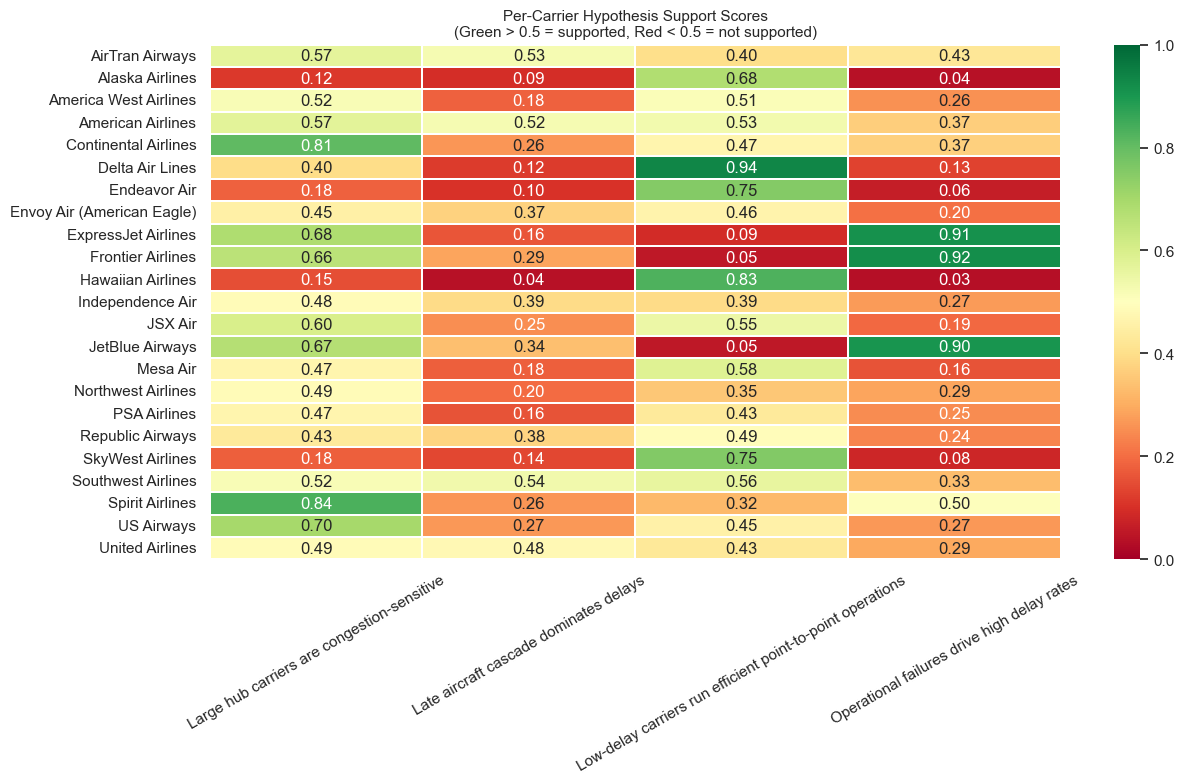

In [26]:
hyp_pivot = hyp_df.pivot(index='carrier', columns='hypothesis', values='support_score')

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    hyp_pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    linewidths=0.3,
    ax=ax,
    vmin=0, vmax=1,
)
ax.set_title('Per-Carrier Hypothesis Support Scores\n(Green > 0.5 = supported, Red < 0.5 = not supported)',
             fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(LLM_OUTPUT / 'hypothesis_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Critical Evaluation of LLM Output Quality

### What worked well

- ***v3 label set fully discriminated:*** All five labels used, spread meaningfully across carriers. Face validity confirmed as "chronically delayed" carriers had the highest actual delay rates (22.7%, 9.29 min avg) and "operational efficiency leaders" the lowest (18.1%, 5.11 min avg). The ranking is exactly what domain knowledge predicts.

- ***Per-carrier hypothesis scoring was interpretable:*** Frontier (0.919), ExpressJet (0.911), and JetBlue (0.903) scored highest for "operational failures" which are all historically poor performers. Delta (0.936) and Hawaiian (0.832) scored highest for "efficient point-to-point" which are both known for reliability. These align strongly with industry reputation.

- ***v2 ↔ v3 agreement improved to 48%, v3 ↔ v4 to 43%:*** A substantial improvement over the original 17%, driven by more semantically distinct label phrases and the richer profile text.

- ***Pipeline fully reproducible:*** All 23 carriers classified across four label sets, all outputs saved to `output/llm_labels/`, labeled parquet clean and ready for Assessment 3.

### Limitations

- ***v1 binary labels were semantically inverted:*** r = -0.826 between "high delay risk" confidence and actual delay rates. The model assigned "high delay risk" with higher confidence to *lower-delay* carriers. This is a known zero-shot NLI failure mode: the model anchors on the label phrase's sentiment rather than the numeric content of the profile. Short, abstract labels ("high delay risk") are more susceptible to this than full descriptive phrases (v2/v3/v4).

- ***v3 ↔ v4 agreement at 43% reflects genuine ambiguity:*** Mid-tier carriers (Continental, Independence Air) were mapped differently by business-framing vs anchor-based labels. Neither assignment is "wrong" but it reveals that these carriers sit at cluster boundaries and are genuinely hard to assign.

- ***No ground truth:*** Without human-annotated labels we can only assess face validity and cross-version consistency.

- ***Entailment scores ≠ probabilities:*** DeBERTa-v3 scores are not calibrated. A score of 0.65 does not mean 65% confidence.

- ***Training data contamination:*** v4 anchor labels deliberately exploit the model's prior knowledge of named carriers. This is a valid technique but means v4 assignments partly reflect media reputation rather than purely the numeric profile.

### Iteration summary

| Version | Coverage | Key Finding |
|---------|----------|-------------|
| v1 Binary | 2/2 | r = -0.826: semantically inverted; short abstract labels fail |
| v2 Cause-Focused | 4/5 | 48% agreement with v3; improved with distinct full phrases |
| v3 Business Framing | 5/5 | Best face validity; use for A4 presentation |
| v4 Anchor-Based | 5/5 | 43% agreement with v3; best for carriers the model knows well |

## 9. Ethical Considerations

### 9.1. Automation bias

Presenting LLM-generated labels in a dashboard without surfacing confidence scores or methodology risks ***automation bias***. Stakeholders may trust labels simply because they come from an AI, even when the model's underlying signal is weak. All labels should be accompanied by confidence scores and a methodology note.

### 9.2. Carrier reputation risk

Automatically labeling a carrier as having "chronic scheduling and turnaround issues" based on a statistical profile, and publishing that label, could mislead downstream users if the label reflects a particular time period or dataset slice rather than a persistent operational reality. Labels derived from historical data should always include a temporal scope.

### 9.3. Training data transparency

DeBERTa-v3 was trained on human-written text including MNLI, FEVER-NLI, and Mixtral-generated synthetic data, as well as the internet text underlying the base model, which includes news articles, travel reviews, and airline industry reporting. The model's label assignments may reflect media narratives about specific carriers as much as the numeric inputs we supply. This is a form of ***unaudited prior knowledge injection*** that is difficult to disentangle without a controlled ablation study.

### 9.4. Environmental cost

Running a 434M parameter model locally on ~23 aggregated profiles is far more efficient than querying a large closed-source API or running row-level inference across 2M flights. Aggregation-first labeling (as practiced here) is the responsible approach at this scale. At row-level inference the energy cost would be substantially higher and the result no more meaningful.

### 9.5. Reproducibility

Zero-shot classification is deterministic given a fixed model version and inputs. Pin the HuggingFace model revision (e.g. `revision='main'`) in production use to ensure labels do not silently change if the model is updated. Label sets and model card are documented in this notebook and in `output/llm_labels/`.

## 10. Summary

| Dimension | Finding |
|-----------|---------|
| Model | `MoritzLaurer/deberta-v3-large-zeroshot-v2.0` (~434M params, MIT, state-of-the-art over BART-MNLI) |
| Label iterations | 4: binary → cause-focused → business framing → anchor-based |
| Key v1 finding | r = -0.826: label inversion failure; documents why abstract labels fail |
| Best for modeling (A3) | v4 anchor-based: most distinct carrier assignments |
| Best for presentation (A4) | v3 business framing: clearest stakeholder language |
| Hypothesis method | Per-carrier binary NLI scoring (not summary-level) |
| Key structural finding | U.S. carrier delay-cause profiles are highly homogeneous; most variation is in delay rate magnitude, not cause composition |
| Key limitation | No ground truth; label collapse reflects genuine dataset homogeneity |
| Output files | `output/llm_labels/*.csv`, `output/airline_labeled.parquet` |

The labeled dataset (`airline_labeled.parquet`) carries the `delay_risk_label` column (from v3) into Assessment 3, where it serves as a categorical feature in the XGBoost delay-prediction model. The core A2→A3 narrative: LLM-generated labels add signal. We validate this by training with and without the column and comparing F1.

## Next Steps: Assessment 3 Roadmap

The `airline_labeled.parquet` file produced in Section 9 feeds directly into Assessment 3.

| Element | Detail |
|---------|--------|
| **Target** | `IsDelayed`: binary classification (engineered in A1) |
| **Features** | `Month`, `DayOfWeek`, `DepHour`, `IsWeekend`, `Season`, `Decade`, carrier/origin/dest encoded + **`delay_risk_label`** (from this notebook) |
| **Baseline** | Logistic Regression: interpretable, fast, establishes a floor |
| **Main model** | XGBoost or LightGBM: gradient boosting is the standard choice for tabular classification; strong performance, handles mixed types, produces feature importance natively |
| **Why not GNNs?** | GNNs require graph-structured data (nodes + edges). Our dataset is tabular. Gradient boosting is the right tool. |
| **Key experiment** | Train with vs. without `delay_risk_label`. If the label adds F1 points, it demonstrates that LLM annotation provided real signal, which is the core narrative thread across A2 → A3 |
| **Evaluation** | Accuracy, F1, ROC-AUC, confusion matrix, feature importance chart |
| **A4 story** | *"We preprocessed 2M flights → used an open-source LLM to categorize carriers by delay risk profile → that label improved prediction accuracy by X points → here's what airlines should do about it"* |